In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import time
import helpers

import environments
import environments.bicycle as bicycle

import controllers.pid as pid
import controllers.stanley as stanley
import controllers.clothoids as clothoids
import controllers.purepursuit as purepursuit

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

from tqdm import tqdm

pygame 2.6.1 (SDL 2.28.4, Python 3.12.8)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
# # Clothoid Based Controller
# controller = clothoids.ClothoidTentaclesController(
#     num_tentacles=41,
#     # Time horizon constant,
#     t0=7.0,
#     # Length offset constant,
#     l0=5.0,
#     num_points_per_tentacle=50,
#
#     wheelbase=1.75,
#     # m/s^2,
#     max_lateral_accel=4.0,
#     # Comfortable braking deceleration,
#     max_decel=1.5,
#
#     # Selection weights (from paper),
#     weight_clearance=0.1,          # a0,
#     weight_curvature=0.2,          # a1,
#     weight_trajectory=0.5,         # a2,
#
#     # Velocity control,
#     # m/s,
#     target_velocity=5.0,
#     kp_velocity=2.0,
# )

# # Pure Pursuit Controller:
# controller = purepursuit.PurePursuitController(
#     lookahead_distance=6.0,
#     min_lookahead=3.0,
#     max_lookahead=12.0,
#     wheelbase=1.75,
#     target_velocity=8.0,
#     kp_velocity=2.0
# )

# Clothoid Tentacles Controller:
# controller = clothoids.ClothoidTentaclesController(
#     num_tentacles=41,
#     t0=7.0, l0=5.0,
#     wheelbase=1.75,
#     target_velocity=5.0,
# )

# # Stanley Controller:
# controller = stanley.StanleyController(
#     # Core gains (Equation 5)
#     k=2.5,                      # Crosstrack gain - controls convergence rate
#     k_soft=1.0,                 # Low-speed softening (prevents high gain at low v)

#     # Dynamics compensation (Equation 9)
#     k_d_yaw=0.3,                # Yaw rate damping - stabilizes at high speeds
#     k_d_steer=0.05,             # Steering servo damping - lead control

#     # Vehicle parameters (must match environment)
#     wheelbase=1.75,
#     front_axle_distance=0.875,  # CG to front axle
#     rear_axle_distance=0.875,   # CG to rear axle

#     # Tire dynamics (from paper: 145 kN/rad for off-road tires)
#     vehicle_mass=1500.0,
#     tire_stiffness=145000.0,

#     # Velocity control (switching PI controller)
#     target_velocity=8.0,        # m/s (~29 km/h)
#     kp_velocity=2.0,
#     ki_velocity=0.1,

#     # Obstacle avoidance
#     obstacle_stop_distance=5.0,
#     obstacle_slow_distance=15.0,
# )

# # PID Controller:
# controller = pid.PIDController(
#     # Lateral control gains
#     kp_lateral=1.0,
#     ki_lateral=0.0,
#     kd_lateral=0.5,
    
#     # Heading control gains
#     kp_heading=2.0,
#     ki_heading=0.0,
#     kd_heading=0.1,
    
#     # Velocity control gains
#     kp_velocity=2.0,
#     ki_velocity=0.1,
#     kd_velocity=0.0,
    
#     # Vehicle parameters
#     wheelbase=1.75,
#     target_velocity=8.0,
#     lookahead_distance=5.0,
# )

In [4]:
import cristal

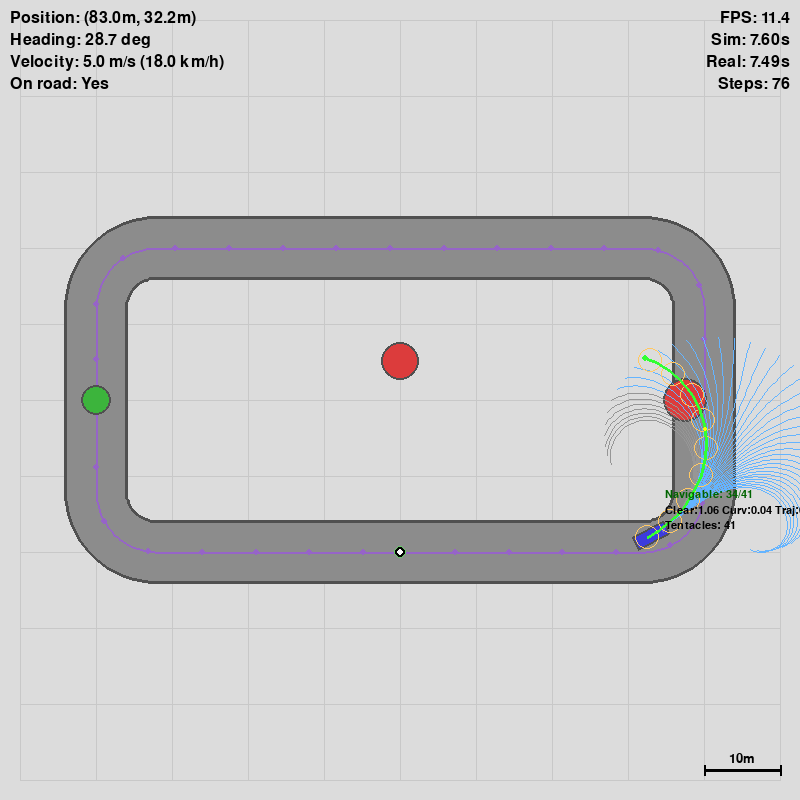

KeyboardInterrupt: 

In [6]:
env = cristal.build_cristal_environment()

controller = clothoids.ClothoidTentaclesController(
    num_tentacles=41,
    # Time horizon constant,
    t0=7.0,
    # Length offset constant,
    l0=5.0,
    num_points_per_tentacle=50,

    wheelbase=1.75,
    # m/s^2,
    max_lateral_accel=4.0,
    # Comfortable braking deceleration,
    max_decel=1.5,

    # Selection weights (from paper),
    weight_clearance=0.1,          # a0,
    weight_curvature=0.2,          # a1,
    weight_trajectory=0.5,         # a2,

    # Velocity control,
    # m/s,
    target_velocity=5.0,
    kp_velocity=2.0,
)

obs, info = env.reset()

for i in range(500):
    action = controller.get_action(
        observation=obs,
        path=env.global_path,
        obstacles=env.obstacles,
        max_steering=env.max_steering,
        max_acceleration=env.max_acceleration,
    )
    
    obs, reward, terminated, truncated, info = env.step(action)
    
    env.overlay_manager.clear()
    controller.draw_debug(env, obs, env.global_path)
    
    helpers.preview(env)

    if terminated or truncated:
        break

env.close()

print(f"\nSimulation completed after {env.performance_tracker.step_count} steps")
print(f"Final position: {obs['position']}")
print(f"Final velocity: {obs['velocity'][0]:.2f} m/s")